03 · Calibration - PEST++ GLM with SVD and Tikhonov (3-layer pilot points)

Run the control file from notebook 02 with PEST++ **GLM**: iterative Gauss-Levenberg-Marquardt with
SVD truncation and Tikhonov regularization. 

1. Imports & paths

In [ ]:
from pathlib import Path
import os
import shutil
import numpy as np, pandas as pd
import pyemu
import flopy
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from helper_fb3_03_v3 import (plot_phi, plot_time_series_fit, plot_one_to_one,
                              regenerate_fields_3l, plot_fields_3l,
                              plot_calibrated_fields, field_log_ranges)

CASE = "freyberg_3l"

from paths import PEST_TEMPLATE as TEMPLATE, PEST_MASTER as MASTER
from paths import FINAL_TRUTH_WS   
NUM_WORKERS = 12           # parallel workers for the GLM Jacobian (338 adj params)
PROPS = ["hk_l1","hk_l2","hk_l3","vk_l1","vk_l2","vk_l3","ss_l1","ss_l2","ss_l3","sy_l1"]

2. Set GLM iterations and write the control file (version=1)

In [63]:
pst = pyemu.Pst(str(TEMPLATE / f"{CASE}.pst"))
pst.control_data.noptmax = 20            # GLM iterations
pst.write(str(TEMPLATE / f"{CASE}.pst"), version=1)
print("adj par:", pst.npar_adj, "| nnz obs:", pst.nnz_obs, "| noptmax:", pst.control_data.noptmax,
      "| PHIMLIM:", pst.reg_data.phimlim)

noptmax:20, npar_adj:228, nnz_obs:36
adj par: 228 | nnz obs: 36 | noptmax: 20 | PHIMLIM: 36.0


3. Run PEST++ GLM in parallel

`start_workers` launches `NUM_WORKERS` MF6 forward runs in parallel to build the Jacobian. With 338
adjustable parameters this is the slow step; reduce parameters (coarser pilot points in 02) if needed.
A serial fallback is commented below.

In [ ]:
from paths import GLM_WORKER_ROOT as WORKER_ROOT

if MASTER.exists():
    shutil.rmtree(MASTER)
if WORKER_ROOT.exists():
    shutil.rmtree(WORKER_ROOT)
WORKER_ROOT.mkdir(parents=True)

pyemu.os_utils.start_workers(
    str(TEMPLATE), "pestpp-glm", f"{CASE}.pst",
    num_workers=NUM_WORKERS, master_dir=str(MASTER), worker_root=str(WORKER_ROOT), verbose=True)

# import subprocess; subprocess.run(["pestpp-glm", f"{CASE}.pst"], cwd=str(TEMPLATE))
print("GLM finished; results in", MASTER)

2026-07-06 10:04:19,064 - MainProcess - INFO - Reserved port 4013 for process 51880


master:pestpp-glm freyberg_3l.pst /h :4013 in C:\workspace\gwmodeling\model_enhanced_fr\runs\pest_master
worker:pestpp-glm freyberg_3l.pst /h localhost:4013 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\glm\worker_0
worker:pestpp-glm freyberg_3l.pst /h localhost:4013 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\glm\worker_1
worker:pestpp-glm freyberg_3l.pst /h localhost:4013 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\glm\worker_2
worker:pestpp-glm freyberg_3l.pst /h localhost:4013 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\glm\worker_3
worker:pestpp-glm freyberg_3l.pst /h localhost:4013 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\glm\worker_4
worker:pestpp-glm freyberg_3l.pst /h localhost:4013 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\glm\worker_5
worker:pestpp-glm freyberg_3l.pst /h localhost:4013 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\glm\worker_6
worker:pestpp-glm freyberg_

4. Reload the control file with results (residuals attached)

In [65]:
pst = pyemu.Pst(str(MASTER / f"{CASE}.pst"))
print("final total phi:", round(pst.phi, 2))
print("phi by group:", {k: round(v, 2) for k, v in pst.phi_components.items()})

final total phi: 41.68
phi by group: {'forecast': np.float64(0.0), 'head': np.float64(31.25), 'sw': np.float64(10.42)}


5. Objective-function (phi) history - measurement phi

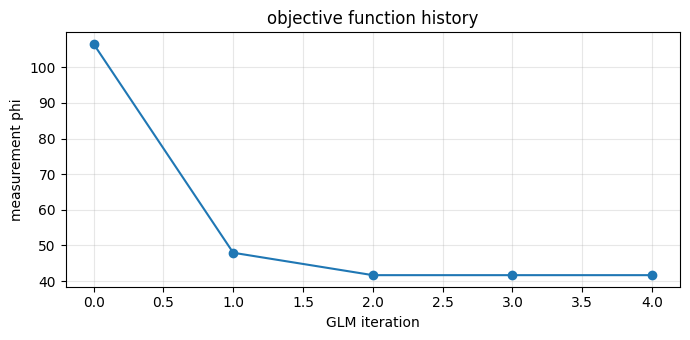

,iteration,model_runs_completed,total_phi,measurement_phi,regularization_phi,head,forecast,sw,regul_cc
2,2,477,42.8785,41.6790,1.19950,31.2555,0,10.4235,1.19950
3,3,715,43.5270,41.6785,1.84846,31.2545,0,10.4240,1.84846
4,4,1181,43.1004,41.6786,1.42188,31.2545,0,10.4241,1.42188


In [66]:
iobj = plot_phi(str(MASTER), CASE); plt.show()
iobj.tail(3)

6. Fit over the history window (observed vs simulated)

In [ ]:
def plot_time_series_fit(pst, n_hist=None):
    """Observed vs simulated per series (sw_1, gw_1, gw_2) over the history window only."""
    
    res = pst.res.set_index("name")
    series = [("sw_1", "m$^3$/d"), ("gw_1", "m"), ("gw_2", "m")]
    label_fs = 18

    fig, axes = plt.subplots(3, 1, figsize=(12, 7), constrained_layout=True)

    for ax, (pre, unit) in zip(axes, series):
        names = sorted(
            [n for n in res.index if n.startswith(pre)],
            key=lambda n: int(n.split("sp")[-1])
        )

        sp = [int(n.split("sp")[-1]) for n in names]

        ax.plot(
            sp, res.loc[names, "measured"],
            "-", marker="o", color="black", lw=1.7, ms=4,
            label="Observed"
        )
        ax.plot(
            sp, res.loc[names, "modelled"],
            "-", marker="o", color="red", lw=1.7, ms=4,
            label="Simulated"
        )

        ax.set_title(f"{pre} obs vs sim", fontsize=label_fs)
        ax.set_ylabel(f"{pre} ({unit})", fontsize=label_fs)

        ax.set_xlim(0, max(sp))
        ax.set_xticks(range(0, max(sp) + 1, 1))

        ax.yaxis.set_major_locator(MaxNLocator(4))
        ax.grid(True, axis="both", alpha=0.3)

    axes[-1].set_xlabel("Stress period", fontsize=label_fs)

    axes[0].legend()

    return fig

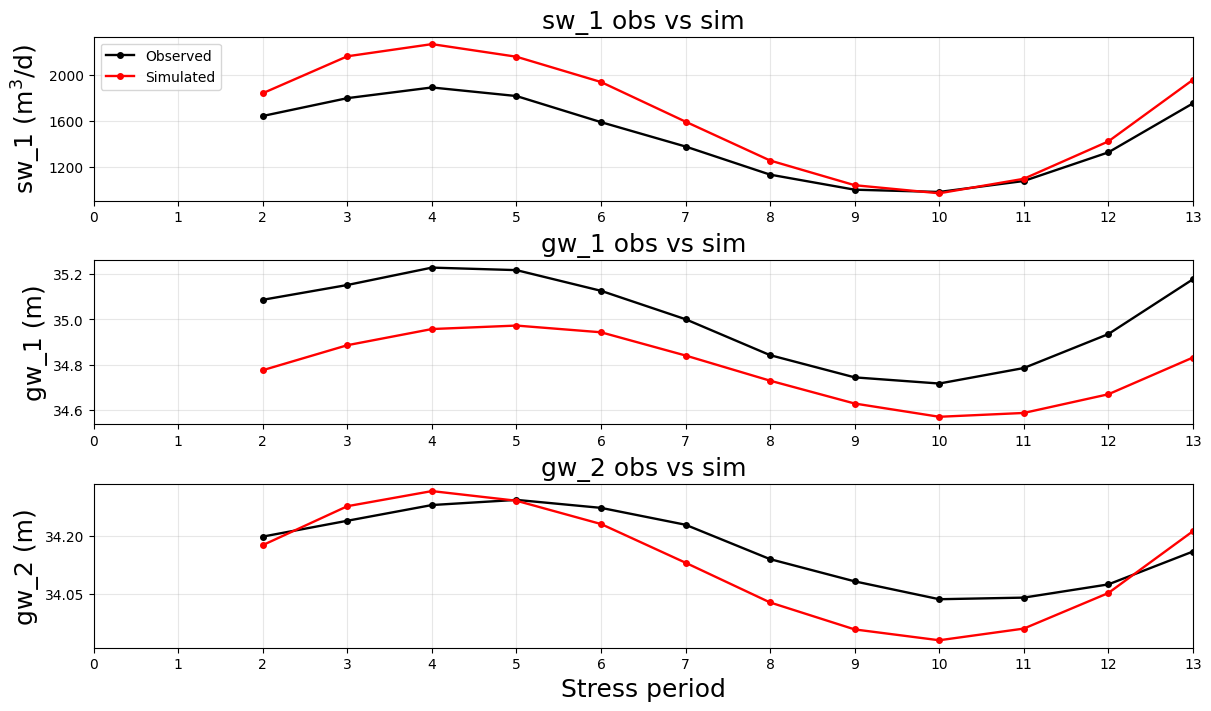

In [92]:
plot_time_series_fit(pst, n_hist=12); plt.show()

7. 1:1 fit for all weighted observations

In [68]:
def plot_one_to_one(pst):
    """Observed vs simulated 1:1 plots, separated by observation series."""
    
    res = pst.res.set_index("name")

    series = [
        ("sw_1", r"m$^3$/d"),
        ("gw_1", "m"),
        ("gw_2", "m"),
    ]

    fig, axes = plt.subplots(
    1, 3,
    figsize=(10, 5),   
    constrained_layout=True,
    gridspec_kw={"wspace": 0.2}
    )

    for ax, (pre, unit) in zip(axes, series):

        # 해당 series의 weighted observation만 선택
        w = res[
            (res["weight"] > 0) &
            (res.index.to_series().str.startswith(pre))
        ]

        if w.empty:
            ax.set_visible(False)
            continue

        obs = w["measured"].astype(float)
        sim = w["modelled"].astype(float)

        # x/y축을 동일 범위로 설정
        lo = min(obs.min(), sim.min())
        hi = max(obs.max(), sim.max())

        pad = 0.05 * (hi - lo)
        if pad == 0:
            pad = 1.0

        lo -= pad
        hi += pad

        ax.scatter(
            obs, sim,
            s=70,
            c="red",
            edgecolor="black",
            linewidth=0.7,
            alpha=0.9,
            zorder=3
        )

        # 1:1 기준선
        ax.plot(
            [lo, hi], [lo, hi],
            "k--",
            lw=1.4,
            zorder=2
        )

        # x/y축 범위와 비율을 같게 유지
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")

        ax.set_xlabel(f"Observed ({unit})", fontsize=14)
        ax.set_ylabel(f"Simulated ({unit})", fontsize=14)
        ax.set_title(f"{pre}: 1:1 fit", fontsize=16)

        ax.tick_params(labelsize=10)
        ax.xaxis.set_major_locator(MaxNLocator(5))
        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.grid(True, alpha=0.3)

    return fig

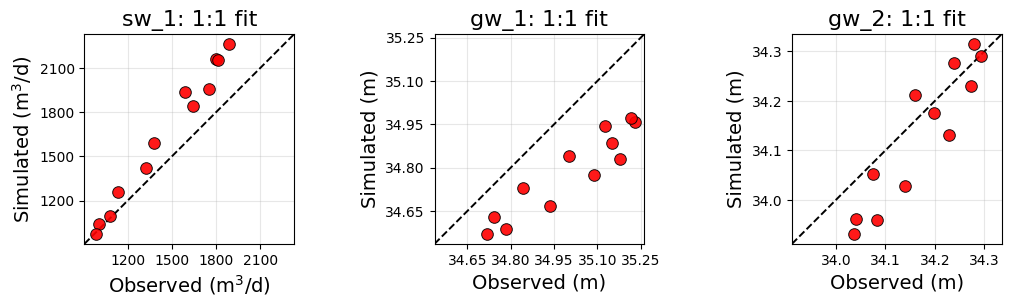

In [69]:
plot_one_to_one(pst); plt.show()

8. Regenerate the calibrated 3-layer property fields (base x best multiplier)

In [70]:
fields = regenerate_fields_3l(str(MASTER), PROPS, shape=(40, 20), fac_file="pp.fac")
for p in PROPS:
    a = fields[p]; print(f"{p}: {a.min():.4g} - {a.max():.4g}")

hk_l1: 3 - 3
hk_l2: 0.3 - 0.3
hk_l3: 30 - 30
vk_l1: 0.3 - 0.3
vk_l2: 0.03 - 0.03
vk_l3: 3 - 3
ss_l1: 1e-06 - 1e-06
ss_l2: 1e-06 - 1e-06
ss_l3: 1e-06 - 1e-06
sy_l1: 0.01 - 0.01


9. Calibrated fields (3 layers)

In [71]:
# best 파라미터를 pp.dat에 반영 (GLM 재실행 X, 디스크의 결과만 사용)
pst.parrep(str(MASTER / f"{CASE}.par"))        # best .par 값 로드
pst.write_input_files(pst_path=str(MASTER))    # *pp.dat를 best multiplier로 다시 씀

fields = {}
for p in PROPS:
    mult = pyemu.geostats.fac2real(str(MASTER / f"{p}pp.dat"),
                                   factors_file=str(MASTER / "pp.fac"), out_file=None)
    mult = np.asarray(mult).reshape(40, 20)
    tag, lay = p.split("_")[0], p.split("_")[1]
    base = np.loadtxt(str(MASTER / f"{tag}_base_{lay}.dat"))
    fields[p] = base * mult
    print(f"{p}: {fields[p].min():.4g} - {fields[p].max():.4g}")

Updating parameter values from C:\workspace\gwmodeling\model_enhanced_fr\runs\pest_master\freyberg_3l.par
parrep: updating noptmax to 0
hk_l1: 3 - 3.003
hk_l2: 0.2999 - 0.3
hk_l3: 26.41 - 30.02
vk_l1: 0.2995 - 0.3001
vk_l2: 0.02993 - 0.03001
vk_l3: 2.997 - 3.001
ss_l1: 1e-06 - 1e-06
ss_l2: 1e-06 - 1e-06
ss_l3: 1e-06 - 1e-06
sy_l1: 0.009921 - 0.01


In [ ]:
par = pst.parameter_data
for p in ["hk_l1", "hk_l3"]:
    vals = par.loc[par.index.str.startswith(p), "parval1"].astype(float)
    print(f"{p}: n={len(vals)}, mult min={vals.min():.3f}, max={vals.max():.3f}, std={vals.std():.3f}")

hk_l1: n=18, mult min=1.000, max=1.001, std=0.000
hk_l3: n=18, mult min=0.880, max=1.001, std=0.028


In [73]:
idomain = np.stack([np.loadtxt(MASTER / f"hk_base_l{k+1}.dat") for k in range(3)]) * 0 + 1  # placeholder
# use the model idomain for masking
gwf = flopy.mf6.MFSimulation.load(sim_ws=str(MASTER), verbosity_level=0).get_model()
idomain = gwf.dis.idomain.array.astype(int)

In [80]:
def plot_calibrated_fields(fields, idomain, vmins=None, vmaxs=None):
    """Notebook-1 4x3 template (HK/VK/SS by layer + SY L1) drawn with the calibrated values.

    Titles / labels / positions are exactly as in notebook 1. Pass vmins/vmaxs (e.g. from
    field_log_ranges(truth_fields, idomain)) to use notebook-1's colour scale; if omitted, the
    ranges are taken from these fields' 2/98 percentiles (which collapse when near-homogeneous).
    """
    final_hk = np.stack([fields[f"hk_l{k+1}"] for k in range(3)])
    final_vk = np.stack([fields[f"vk_l{k+1}"] for k in range(3)])
    final_ss = np.stack([fields[f"ss_l{k+1}"] for k in range(3)])
    final_sy = fields["sy_l1"]

    fig, axes = plt.subplots(4, 3, figsize=(8, 12), constrained_layout=True)
    fields = [
        final_hk,
        final_vk,
        final_ss,
        final_sy
    ]
    param_names = [
        r"$\log_{10} K$",
        r"$\log_{10} K_{33}$",
        r"$\log_{10} S_s$",
        r"$\log_{10} S_y$"
    ]
    if vmins is None or vmaxs is None:
        vmins = []
        vmaxs = []
        for i in range(4):
            if i == 3:
                arr = np.log10(fields[i])
                arr[idomain[0, :, :] <= 0] = np.nan
                vals = arr[np.isfinite(arr)]
            else:
                arr = np.log10(fields[i])
                arr[idomain <= 0] = np.nan
                vals = arr[np.isfinite(arr)]
            vmins.append(np.percentile(vals, 2))
            vmaxs.append(np.percentile(vals, 98))
    for i in range(4):
        for j in range(3):
            ax = axes[i, j]
            if i == 3:
                if j != 0:
                    ax.axis("off")
                    continue
                field = np.log10(fields[i]).copy()
                field[idomain[0, :, :] <= 0] = np.nan
            else:
                field = np.log10(fields[i][j]).copy()
                field[idomain[j, :, :] <= 0] = np.nan
            im = ax.imshow(
                field,
                origin="upper",
                vmin=vmins[i],
                vmax=vmaxs[i],
                cmap="jet"
            )
            ax.tick_params(axis='both', which='major', labelsize=10)
            if i == 3:
                ax.set_title(param_names[i])
            else:
                ax.set_title(f"{param_names[i]}, L{j+1}")
                ax.set_xlabel("column", fontsize='11')
                ax.set_ylabel("row", fontsize='11')

            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="8%", pad=0.05)
            fig.colorbar(im, cax=cax)


    axes[3, 1].axis("off")
    axes[3, 2].axis("off")
    return fig

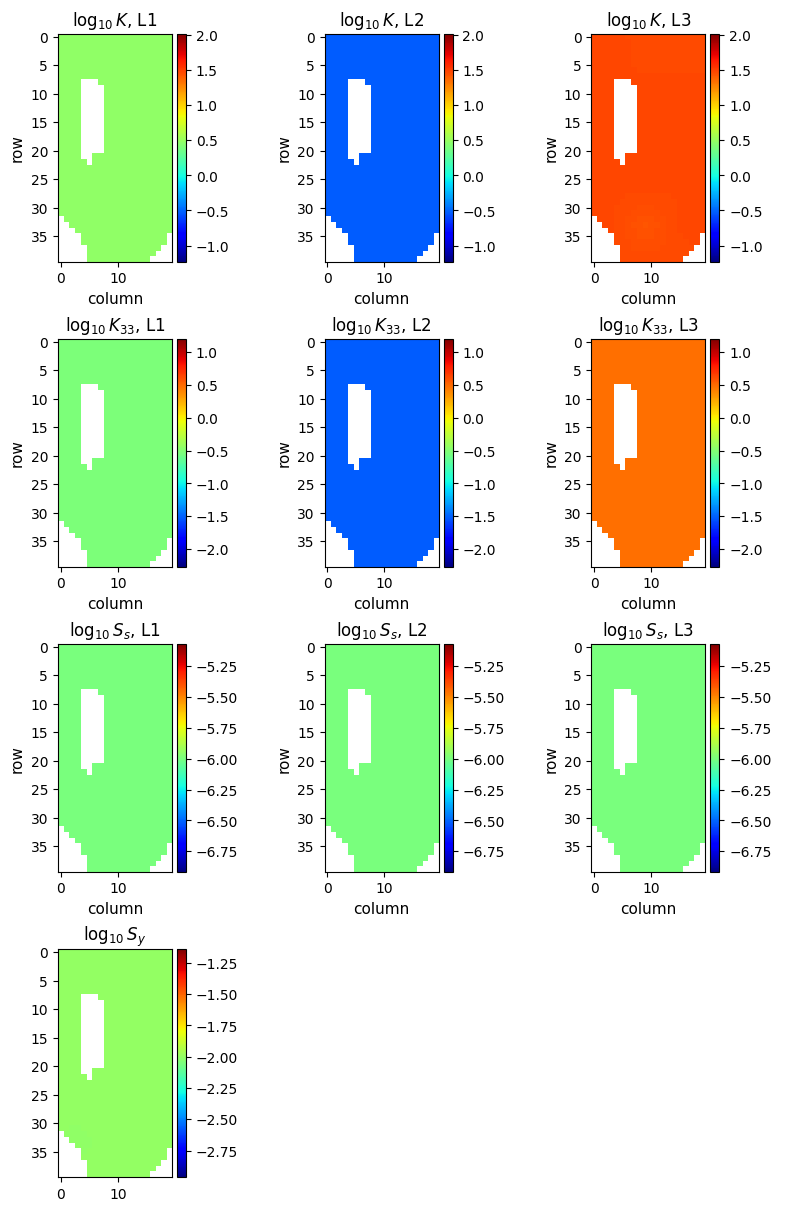

In [83]:
tgwf = flopy.mf6.MFSimulation.load(sim_ws=str(FINAL_TRUTH_WS), verbosity_level=0).get_model()
truth_fields = {}
for k in range(3):
    truth_fields[f"hk_l{k+1}"] = tgwf.npf.k.array[k]
    truth_fields[f"vk_l{k+1}"] = tgwf.npf.k33.array[k]
    truth_fields[f"ss_l{k+1}"] = tgwf.sto.ss.array[k]
truth_fields["sy_l1"] = tgwf.sto.sy.array[0]

vmins, vmaxs = field_log_ranges(truth_fields, idomain)     
plot_calibrated_fields(fields, idomain, vmins=vmins, vmaxs=vmaxs)
plt.show()

10. Calibrated forecast values (simulated; truth not used here)

In [87]:
res = pst.res.set_index("name")
fore = ["tailwater_sp13", "headwater_sp22", "gw_3_sp22"]
fc = res.loc[fore, ["modelled"]].rename(columns={"modelled": "calibrated_forecast"})
from paths import TABLES_DIR as TABLES; TABLES.mkdir(parents=True, exist_ok=True)
fc.to_csv(TABLES / "forecast_calibrated.csv")
fc

,calibrated_forecast
name,
tailwater_sp13,-838.936404
headwater_sp22,-391.299599
gw_3_sp22,34.833689
